## Multilingual V2 Dataset Analysis

#### This section analyzes Dataset Version 2, which combines the English baseline feature dataset with Sinhala-English and Tamil-English code-mixed phishing samples. The purpose of this analysis is to verify the multilingual dataset structure, category distribution, language distribution, and train-validation-test split before training the multilingual model.

### (1) Load V2 Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Detect project root folder
BASE_DIR = Path.cwd()

# If notebook is running from notebooks/ folder, move one level up
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
DATA_FEATURES = DATA_DIR / "features"
DATA_FEATURES_V2 = DATA_DIR / "features_v2"
REPORT_FIGURES = BASE_DIR / "reports" / "figures"

REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", BASE_DIR)
print("Features V2 folder:", DATA_FEATURES_V2)

Project root: d:\CSCI4018 - Research project - Phishing Email Detection
Features V2 folder: d:\CSCI4018 - Research project - Phishing Email Detection\data\features_v2


In [8]:
FEATURES_V2 = DATA_FEATURES_V2

master_v2 = pd.read_csv(FEATURES_V2 / "master_features_v2.csv", low_memory=False)
train_v2 = pd.read_csv(FEATURES_V2 / "train_features_v2.csv", low_memory=False)
val_v2 = pd.read_csv(FEATURES_V2 / "validation_features_v2.csv", low_memory=False)
test_v2 = pd.read_csv(FEATURES_V2 / "test_features_v2.csv", low_memory=False)

print("Master V2 shape:", master_v2.shape)
print("Train V2 shape:", train_v2.shape)
print("Validation V2 shape:", val_v2.shape)
print("Test V2 shape:", test_v2.shape)

Master V2 shape: (60063, 28)
Train V2 shape: (42044, 28)
Validation V2 shape: (9009, 28)
Test V2 shape: (9010, 28)


### (2) Category Distribution

In [9]:
v2_category_counts = master_v2["category"].value_counts()
v2_category_percentages = master_v2["category"].value_counts(normalize=True) * 100

v2_category_summary = pd.DataFrame({
    "count": v2_category_counts,
    "percentage": v2_category_percentages.round(2)
})

v2_category_summary

,count,percentage
category,,
Legitimate,19564,32.57
Traditional_Phishing,17548,29.22
Spam,15659,26.07
AI_Generated_Phishing,4000,6.66
Business_Email_Compromise,3292,5.48


#### The category distribution shows how the English baseline classes and multilingual phishing classes are represented in Dataset Version 2. This is important because the multilingual dataset adds more phishing-related samples to support code-mixed phishing detection.

### (3) Category Distribution Chart

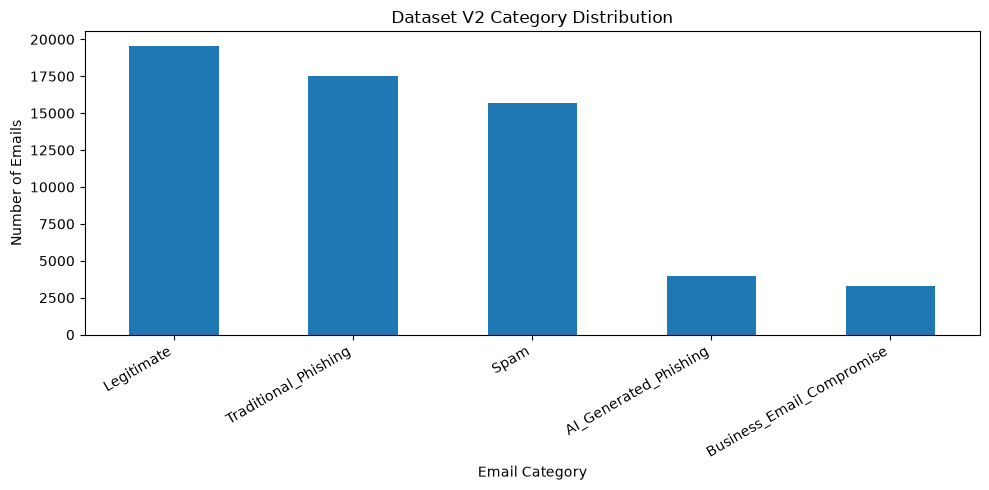

In [10]:
v2_category_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Dataset V2 Category Distribution")
plt.xlabel("Email Category")
plt.ylabel("Number of Emails")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "v2_category_distribution.png", dpi=200)
plt.show()

### (4) Language Distribution

In [11]:
v2_language_counts = master_v2["detected_language"].value_counts()

v2_language_counts

detected_language
English                      40061
CodeMixed_Sinhala_English    10000
CodeMixed_Tamil_English      10000
Unknown                          2
Name: count, dtype: int64

### (5) Language Distribution Chart

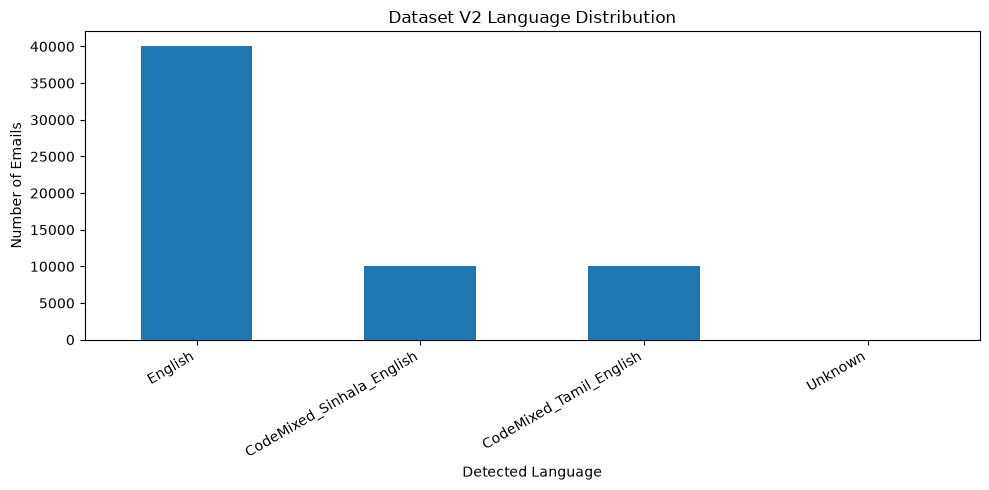

In [12]:
v2_language_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Dataset V2 Language Distribution")
plt.xlabel("Detected Language")
plt.ylabel("Number of Emails")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "v2_language_distribution.png", dpi=200)
plt.show()

#### The language distribution confirms whether Dataset Version 2 includes English, Sinhala-English code-mixed, and Tamil-English code-mixed emails. This supports the multilingual objective of the project.

### (6) Train / Validation / Test Split Check

In [13]:
v2_split_summary = pd.DataFrame({
    "train": train_v2["category"].value_counts(),
    "validation": val_v2["category"].value_counts(),
    "test": test_v2["category"].value_counts()
}).fillna(0).astype(int)

v2_split_summary["total"] = v2_split_summary.sum(axis=1)

v2_split_summary

,train,validation,test,total
category,,,,
Legitimate,13695,2934,2935,19564
Traditional_Phishing,12284,2632,2632,17548
Spam,10961,2349,2349,15659
AI_Generated_Phishing,2800,600,600,4000
Business_Email_Compromise,2304,494,494,3292


### (7) Split Percentage

In [14]:
v2_split_percentage = v2_split_summary[["train", "validation", "test"]].div(
    v2_split_summary["total"], axis=0
) * 100

v2_split_percentage.round(2)

,train,validation,test
category,,,
Legitimate,70.00,15.00,15.00
Traditional_Phishing,70.00,15.00,15.00
Spam,70.00,15.00,15.00
AI_Generated_Phishing,70.00,15.00,15.00
Business_Email_Compromise,69.99,15.01,15.01


### (8) Split Distribution Chart

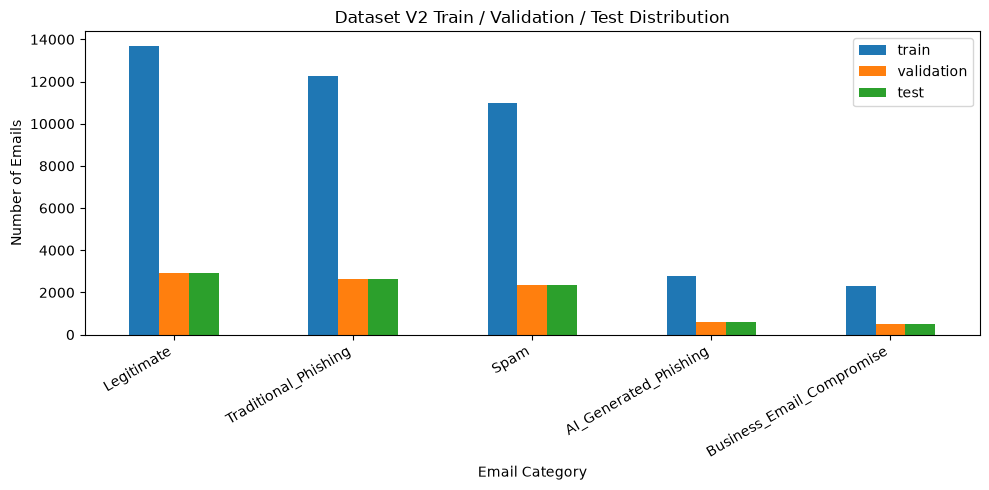

In [15]:
v2_split_summary[["train", "validation", "test"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Dataset V2 Train / Validation / Test Distribution")
plt.xlabel("Email Category")
plt.ylabel("Number of Emails")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_FIGURES / "v2_split_distribution.png", dpi=200)
plt.show()

### (9) Compare V1 and V2 Dataset Sizes

In [17]:
master_features = pd.read_csv(DATA_FEATURES / "master_features.csv", low_memory=False)

print("V1 master features shape:", master_features.shape)
print("V2 master features shape:", master_v2.shape)

V1 master features shape: (40063, 28)
V2 master features shape: (60063, 28)


In [18]:
comparison_df = pd.DataFrame({
    "Dataset Version": ["V1 English Baseline", "V2 English + Code-Mixed"],
    "Total Rows": [len(master_features), len(master_v2)],
    "Number of Categories": [
        master_features["category"].nunique(),
        master_v2["category"].nunique()
    ],
    "Number of Languages": [
        master_features["detected_language"].nunique(),
        master_v2["detected_language"].nunique()
    ]
})

comparison_df

,Dataset Version,Total Rows,Number of Categories,Number of Languages
0,V1 English Baseline,40063,4,2
1,V2 English + Code-Mixed,60063,5,4


#### Dataset Version 1 represents the English baseline dataset, while Dataset Version 2 extends the dataset with Sinhala-English and Tamil-English code-mixed phishing samples. This allows the project to compare English-only phishing detection with multilingual/code-mixed phishing detection.

### (10) Sample Code-Mixed Emails

In [19]:
code_mixed_samples = master_v2[
    master_v2["detected_language"].isin([
        "CodeMixed_Sinhala_English",
        "CodeMixed_Tamil_English"
    ])
]

code_mixed_samples[
    ["email_id", "category", "detected_language", "subject", "body"]
].head(10)

,email_id,category,detected_language,subject,body
40063,CM_000001,Traditional_Phishing,CodeMixed_Sinhala_English,Urgent bank update,"Dear customer, ඔබගේ account එක verify කරන්න. P..."
40064,CM_000002,Traditional_Phishing,CodeMixed_Sinhala_English,University portal notice,"Hello user, security update එක complete කරන්න...."
40065,CM_000003,Traditional_Phishing,CodeMixed_Sinhala_English,Account verification required,"Dear customer, ඔබගේ account එක verify කරන්න. P..."
40066,CM_000004,Traditional_Phishing,CodeMixed_Sinhala_English,Salary confirmation needed,Security team notice: ඔබගේ password එක expire ...
40067,CM_000005,AI_Generated_Phishing,CodeMixed_Sinhala_English,Account verification required,"To avoid interruption, complete the verificati..."
40068,CM_000006,Traditional_Phishing,CodeMixed_Sinhala_English,Salary confirmation needed,"Dear member, payment issue එකක් detect විය. Ac..."
40069,CM_000007,Traditional_Phishing,CodeMixed_Sinhala_English,Payment hold notification,"Dear member, payment issue එකක් detect විය. Ac..."
40070,CM_000008,Traditional_Phishing,CodeMixed_Sinhala_English,Urgent bank update,Security team notice: ඔබගේ password එක expire ...
40071,CM_000009,Traditional_Phishing,CodeMixed_Sinhala_English,Salary confirmation needed,"Hello user, security update එක complete කරන්න...."
40072,CM_000010,AI_Generated_Phishing,CodeMixed_Sinhala_English,Salary confirmation needed,The request will be closed if confirmation is ...


## Summary of V2 Analysis

#### The V2 dataset analysis confirms that the project has been extended from an English-only baseline dataset to a multilingual dataset containing Sinhala-English and Tamil-English code-mixed phishing emails. The category and language distributions were analyzed, and the train-validation-test split was verified. This dataset will be used to train the multilingual model using character n-gram TF-IDF with structured features.